# `color_system` tutorial

This notebook teaches `empylib.color_system.spectrum_to_hex` in its three main modes: a material under a standard illuminant, a self-luminous emitter, and a material seen under a custom illuminant spectrum.

**Learning goals**

- convert a reflectance-like spectrum into sRGB color under D65
- convert an emitter spectrum directly into sRGB
- use a custom illuminant when the viewing conditions matter

**Notebook design**

- every runnable cell calls the public `empylib` API directly
- parameter meanings are explained in markdown and in short inline comments
- outputs are inspected in the same notebook so you can see what each function returns
- the core path is offline-first; internet-backed examples live in clearly marked optional appendices

In [1]:
from pathlib import Path
import os
import sys

current = Path.cwd().resolve()
for candidate in (current, *current.parents):
    if (candidate / "empylib").exists() and (candidate / "docs").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the EMPI Lib repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 3)

import empylib.color_system as cs
import empylib.ref_spectra as ref

## Material color under a standard illuminant

**Functions used**

- cs.spectrum_to_hex

**Problem we are solving**

A reflectance or transmittance spectrum is not a color by itself. To obtain a display color you must specify the viewing illuminant and convert the spectral response into XYZ and then sRGB.

**Parameter guide for this example**

- `wls_um`: visible wavelength grid in micrometers
- `values`: reflectance-like factor in the 0-1 range
- `source='material'`: tells the function to interpret the spectrum as a material factor rather than an emitter SPD
- `illuminant_name='D65'`: standard daylight illuminant used for the color appearance calculation

**Outputs to inspect**

- `hex_color`: HTML-style color string
- `rgb01`: gamma-encoded sRGB values in the 0-1 range
- `rgb255`: 8-bit integer RGB triplet

hex_color: #ffb460
rgb01: (1.0, 0.7039870363539779, 0.37651006909643275)
rgb255: (255, 180, 96)


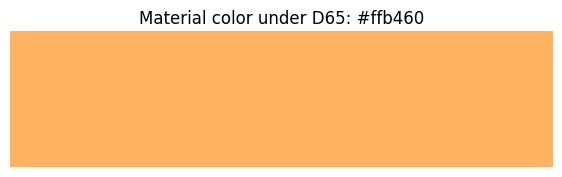

In [2]:
lam = np.linspace(0.38, 0.78, 201)
reflectance = 0.15 + 0.75 * np.exp(-((lam - 0.62) / 0.08) ** 2)

hex_color, rgb01, rgb255 = cs.spectrum_to_hex(
    lam,
    reflectance,         # material reflectance-like spectrum
    source="material",   # interpret the spectrum as a material factor
    illuminant_name="D65",
)

print("hex_color:", hex_color)
print("rgb01:", rgb01)
print("rgb255:", rgb255)

swatch = np.ones((30, 120, 3))
swatch[..., 0] = rgb01[0]
swatch[..., 1] = rgb01[1]
swatch[..., 2] = rgb01[2]

fig, ax = plt.subplots()
ax.imshow(swatch)
ax.set_axis_off()
ax.set_title(f"Material color under D65: {hex_color}")
plt.show()

**How to read the result**

This is the standard material-color workflow for a display-oriented result. The spectrum is weighted by the illuminant and the human observer model before it is mapped to sRGB.

**Common pitfalls**

- The visible wavelength grid must overlap the observer color-matching functions
- For `source='material'`, values outside 0-1 are clipped because they are treated like reflectance or transmittance factors

**Try this next**

- Replace the synthetic reflectance with a measured visible reflectance curve
- Try `illuminant_name='A'` to mimic a warmer tungsten-like viewing condition

## Emitter color

**Functions used**

- cs.spectrum_to_hex

**Problem we are solving**

For a self-luminous source, the spectrum is interpreted as emitted power rather than a reflectance factor. No external illuminant is needed in that case.

**Parameter guide for this example**

- `source='emitter'`: switch to the emitter branch of the color model
- `emitter_units='per_um'`: the spectral power density is given per micrometer in this example
- `values`: emitter spectral power density, here built from a Planck spectrum

**Outputs to inspect**

- the same three color outputs as before, now derived from the emitter SPD

In [3]:
emitter_spd = ref.Bplanck(
    lam,
    T=2600,               # blackbody-like emitter temperature in Kelvin
    unit="wavelength",
)

hex_emitter, rgb01_emitter, rgb255_emitter = cs.spectrum_to_hex(
    lam,
    emitter_spd,
    source="emitter",
    emitter_units="per_um",  # SPD is sampled per micrometer
)

print("hex_emitter:", hex_emitter)
print("rgb01_emitter:", rgb01_emitter)
print("rgb255_emitter:", rgb255_emitter)

hex_emitter: #ffe671
rgb01_emitter: (1.0, 0.9000386920333477, 0.44360163225578825)
rgb255_emitter: (255, 230, 113)


**How to read the result**

Emitter mode is the right choice for blackbodies, LEDs, or any self-luminous source. The absolute power scale does not affect the reported color because the spectrum is normalized during the color conversion.

**Common pitfalls**

- Do not use `source='material'` for an emitter spectrum; that would incorrectly apply an external illuminant model
- Set `emitter_units` correctly so the numerical integration uses the right density convention

**Try this next**

- Increase the temperature to see the color move toward a cooler white
- Pass a measured lamp spectrum instead of a Planck curve

## Material color under a custom illuminant

**Functions used**

- cs.spectrum_to_hex

**Problem we are solving**

Sometimes the standard illuminants are not what matters. This example uses AM1.5G as a custom viewing illuminant so the perceived material color reflects a solar-like source spectrum.

**Parameter guide for this example**

- `illuminant=(wavelength, solar_spd)`: custom illuminant given as wavelength grid plus spectral power density
- `illuminant_units='per_um'`: units of that custom illuminant spectrum
- `source='material'`: still a material factor, so the illuminant matters

**Outputs to inspect**

- material color under the custom source and a plot of the illuminant spectrum used

hex_custom: #ccf2b3
rgb01_custom: (0.8001853579116733, 0.9507940089369565, 0.700581065659386)
rgb255_custom: (204, 242, 179)


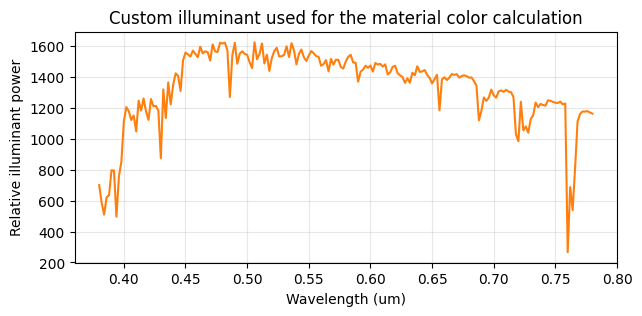

In [4]:
reflectance_custom = 0.20 + 0.70 * np.exp(-((lam - 0.55) / 0.10) ** 2)
solar = ref.AM15(
    lam,
    spectra_type="global",
)

hex_custom, rgb01_custom, rgb255_custom = cs.spectrum_to_hex(
    lam,
    reflectance_custom,
    source="material",
    illuminant=(lam, solar),   # custom illuminant spectrum on the same wavelength grid
    illuminant_units="per_um", # AM1.5 was sampled per micrometer
)

print("hex_custom:", hex_custom)
print("rgb01_custom:", rgb01_custom)
print("rgb255_custom:", rgb255_custom)

fig, ax = plt.subplots()
ax.plot(lam, solar, color="tab:orange")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Relative illuminant power")
ax.set_title("Custom illuminant used for the material color calculation")
ax.grid(True, alpha=0.3)
plt.show()

**How to read the result**

Custom illuminants matter whenever the viewing source is part of the physical question. Outdoor solar appearance, indoor lighting, or spectrally unusual lamps can all change the perceived color of the same material spectrum.

**Common pitfalls**

- The custom illuminant grid and the material spectrum must overlap in wavelength
- Keep the `illuminant_units` consistent with how the illuminant spectrum was generated

**Try this next**

- Swap AM1.5G for a blackbody lamp spectrum and compare the resulting hex code
- Use a measured transmittance instead of reflectance to estimate filter color